In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

df = pd.read_csv("/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv")
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

In [3]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isna().sum())
print(df.isnull().sum()) #нулевой глюкозы не бывает, например

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

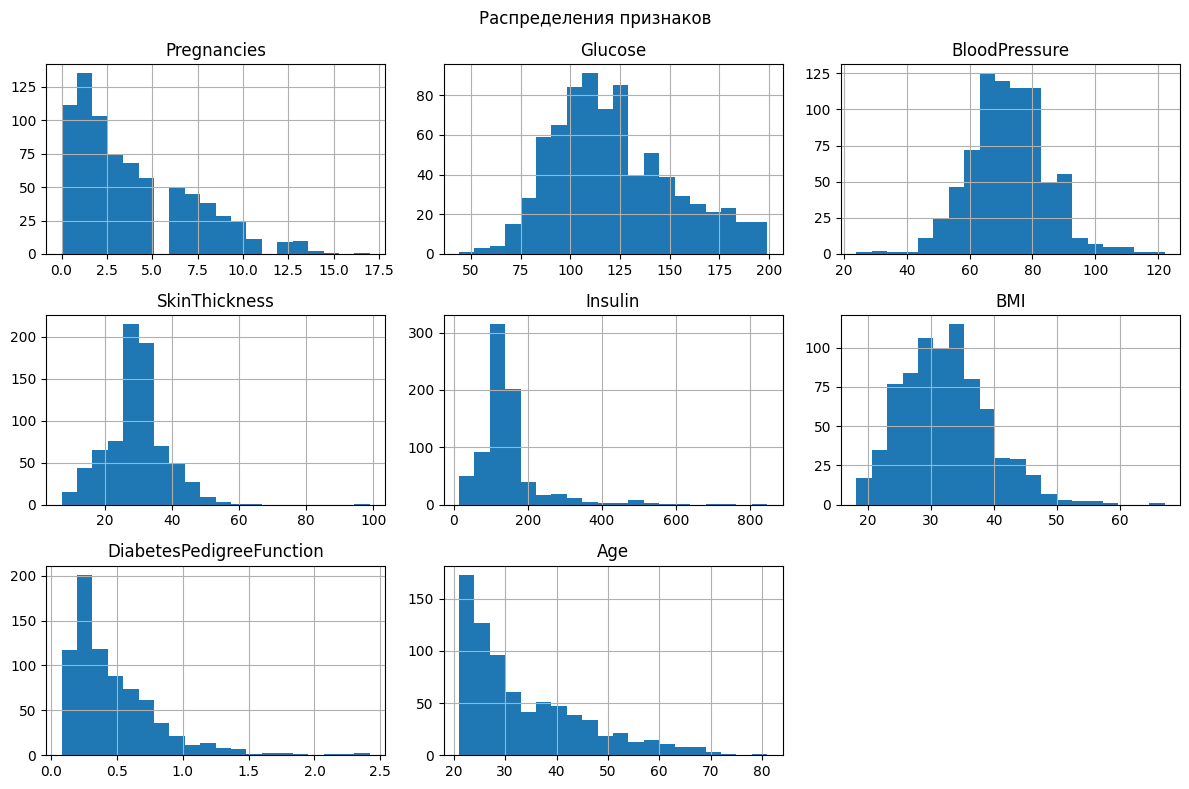

In [4]:
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

df[features].hist(figsize=(12, 8), bins=20)
plt.suptitle('Распределения признаков')
plt.tight_layout()
plt.show()

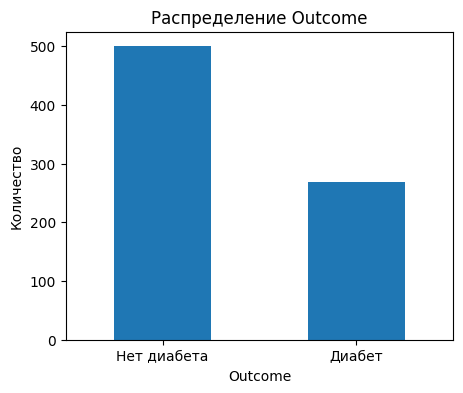

In [5]:
df['Outcome'].value_counts().plot(
    kind='bar',
    figsize=(5, 4)
)

plt.title('Распределение Outcome')
plt.xlabel('Outcome')
plt.ylabel('Количество')
plt.xticks([0, 1], ['Нет диабета', 'Диабет'], rotation=0)
plt.show()

In [6]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (614, 8)
Test: (154, 8)


In [7]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000))])

In [8]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

Чтобы построить матрицу ошибок и посчитать метрики, надо сперва определиться с порогом.

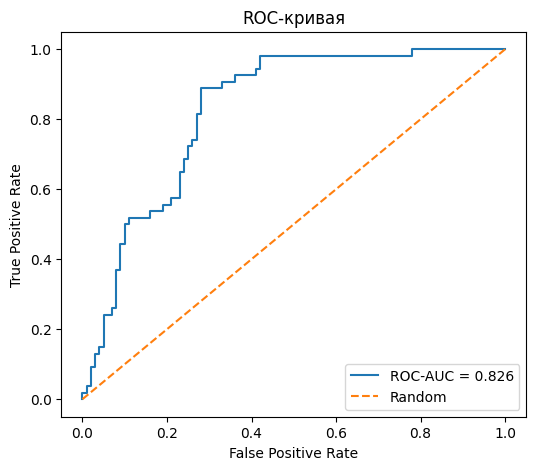

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc:.3f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Random'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

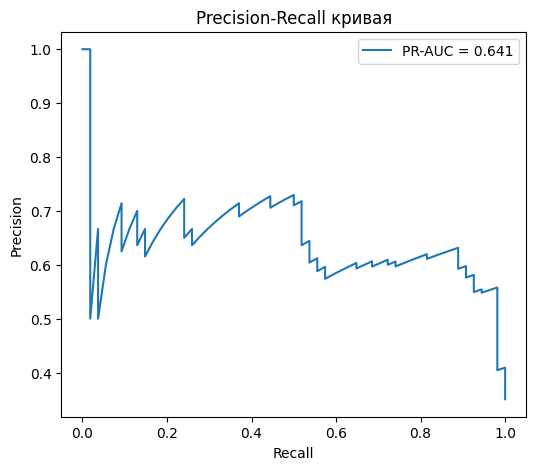

In [10]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(6, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f'PR-AUC = {pr_auc:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая')
plt.legend()
plt.show()

Порог должен отдать приоритет Recall, т.к. речь о диабете, и пропустить диагноз дороже, чем ложная тревога. Попробуем подобрать такой порог, который максимизирует F1.

При этом подбирать порог на тесте будет слегка, но накруткой результата. Так что надо выделить валидацию.

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [12]:
y_val_prob = model.predict_proba(X_val)[:, 1]

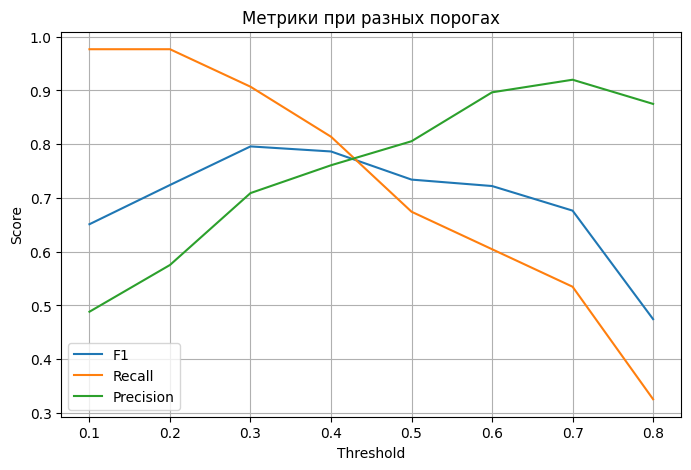

In [13]:
thresholds = np.arange(0.1, 0.9, 0.1) #грубый шаг 0.1 - для учебной задачи

f1_scores = []
recall_scores = []
precision_scores = []

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    f1_scores.append(f1_score(y_val, y_val_pred))
    recall_scores.append(recall_score(y_val, y_val_pred))
    precision_scores.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8, 5))

plt.plot(thresholds, f1_scores, label='F1')
plt.plot(thresholds, recall_scores, label='Recall')
plt.plot(thresholds, precision_scores, label='Precision')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Метрики при разных порогах')
plt.legend()
plt.grid()
plt.show()

Для учебной задачи, выберем по оптимальному F1. В реальной жизни здесь нужно было бы подойти к супервайзеру (заказчик, научный консультант... вот тот человек, которого посадят вместо нас, если что-то пойдет не так) и попросить тз: какая доля ложноотрицательных его устраивает.

In [14]:
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f'Оптимальный threshold: {best_threshold:.2f}')
print(f'F1:        {f1_scores[best_index]:.3f}')
print(f'Recall:    {recall_scores[best_index]:.3f}')
print(f'Precision: {precision_scores[best_index]:.3f}')

Оптимальный threshold: 0.30
F1:        0.796
Recall:    0.907
Precision: 0.709


In [15]:
y_test_prob = model.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_prob >= best_threshold).astype(int)

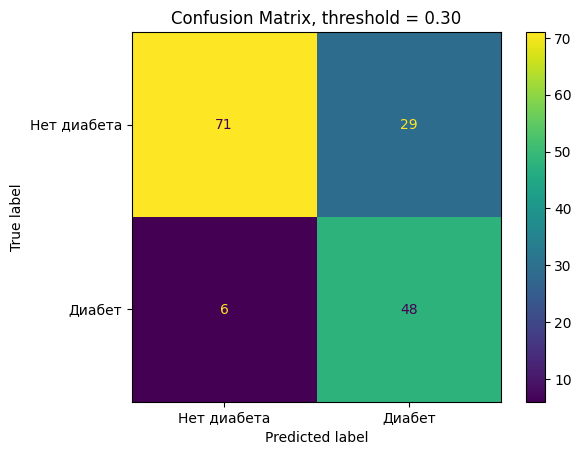

In [16]:
cm = confusion_matrix(y_test, y_test_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Нет диабета', 'Диабет']
).plot()

plt.title(f'Confusion Matrix, threshold = {best_threshold:.2f}')
plt.show()

In [17]:
print('Accuracy:', accuracy_score(y_test, y_test_pred))
print('Precision:', precision_score(y_test, y_test_pred))
print('Recall:', recall_score(y_test, y_test_pred))
print('F1:', f1_score(y_test, y_test_pred))

Accuracy: 0.7727272727272727
Precision: 0.6233766233766234
Recall: 0.8888888888888888
F1: 0.732824427480916


Про метрики.

С нашим порогом модель правильно классифицирует около 77% пациентов. При этом Accuracy недостаточно (вопрос задания) потому, что она не показывает, какие именно ошибки модель совершает. Пропущенный диабет (инвалидность) и ложноположительный диабет (очень недовольный пациент, одно лишнее перетестирование) - это разные вещи, их в нашем случае нельзя так просто усреднять.

Recall высокий (0.89), то есть модель обнаруживает большинство пациентов с диабетом. Precision ниже (0.62): среди предсказанных случаев диабета значительная часть оказывается ложноположительной. Собственно, потому, что мы так настроили порог. 

F1 = 0.73 отражает компромисс между Recall и Precision. В отличие от Accuracy, он не дает обманчиво завышенных результатов, когда одна из двух метрик стремится к единице, а вторая - очень маленькая, т.к. использует гармоническое среднее.

Добавили задачу: обучить модель с weight_class = balanced. Резонно. Дисбаланс легкий, но есть.

In [18]:
balanced_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

balanced_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [19]:
y_val_prob = model.predict_proba(X_val)[:, 1]
y_val_prob_balanced = balanced_model.predict_proba(X_val)[:, 1]

Теперь наглядно выведем разницу.

In [20]:
thresholds = np.arange(0.1, 0.9, 0.1)

f1_scores_balanced = []
recall_scores_balanced = []
precision_scores_balanced = []

for threshold in thresholds:
    y_val_pred_balanced = (
        y_val_prob_balanced >= threshold
    ).astype(int)

    f1_scores_balanced.append(
        f1_score(y_val, y_val_pred_balanced)
    )

    recall_scores_balanced.append(
        recall_score(y_val, y_val_pred_balanced)
    )

    precision_scores_balanced.append(
        precision_score(y_val, y_val_pred_balanced)
    )

best_index_balanced = np.argmax(f1_scores_balanced)
best_threshold_balanced = thresholds[best_index_balanced]

print(f'Оптимальный threshold: {best_threshold_balanced:.2f}')
print(f'F1:        {f1_scores_balanced[best_index_balanced]:.3f}')
print(f'Recall:    {recall_scores_balanced[best_index_balanced]:.3f}')
print(f'Precision: {precision_scores_balanced[best_index_balanced]:.3f}')

Оптимальный threshold: 0.50
F1:        0.804
Recall:    0.860
Precision: 0.755


In [21]:
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

y_pred_balanced = (
    y_prob_balanced >= best_threshold_balanced
).astype(int)

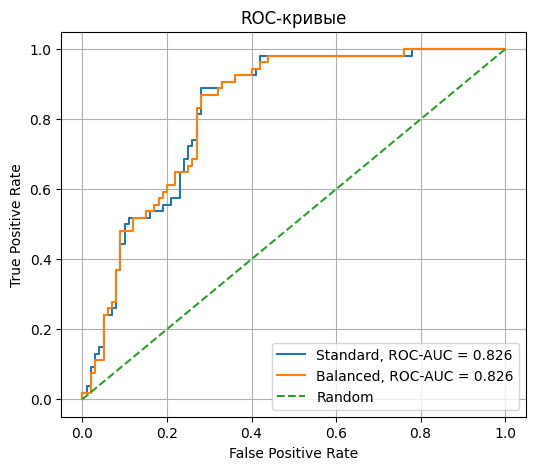

In [22]:
fpr_balanced, tpr_balanced, thresholds_balanced = roc_curve(
    y_test,
    y_prob_balanced
)

roc_auc_balanced = roc_auc_score(
    y_test,
    y_prob_balanced
)

plt.figure(figsize=(6, 5))

# Стандартная модель
plt.plot(
    fpr,
    tpr,
    label=f'Standard, ROC-AUC = {roc_auc:.3f}'
)

# Balanced модель
plt.plot(
    fpr_balanced,
    tpr_balanced,
    label=f'Balanced, ROC-AUC = {roc_auc_balanced:.3f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Random'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid()
plt.show()

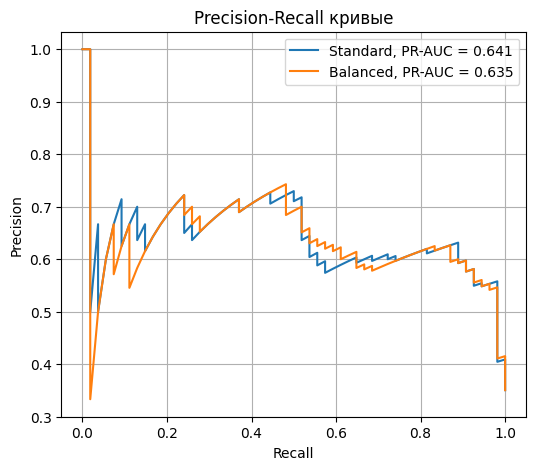

In [23]:
precision_balanced, recall_balanced, thresholds_balanced = precision_recall_curve(
    y_test,
    y_prob_balanced
)

pr_auc_balanced = auc(
    recall_balanced,
    precision_balanced
)

plt.figure(figsize=(6, 5))

# Стандартная модель
plt.plot(
    recall_curve,
    precision_curve,
    label=f'Standard, PR-AUC = {pr_auc:.3f}'
)

# Balanced модель
plt.plot(
    recall_balanced,
    precision_balanced,
    label=f'Balanced, PR-AUC = {pr_auc_balanced:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривые')
plt.legend()
plt.grid()
plt.show()

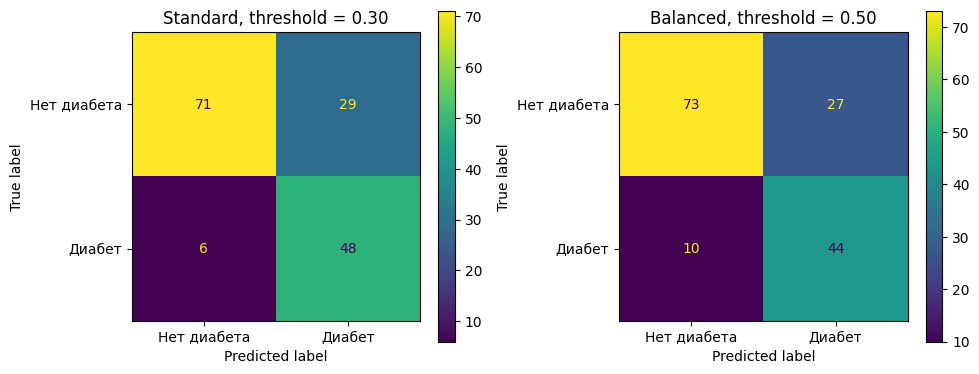

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_test_pred),
    display_labels=['Нет диабета', 'Диабет']
).plot(ax=axes[0])

axes[0].set_title(
    f'Standard, threshold = {best_threshold:.2f}'
)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_balanced),
    display_labels=['Нет диабета', 'Диабет']
).plot(ax=axes[1])

axes[1].set_title(
    f'Balanced, threshold = {best_threshold_balanced:.2f}'
)

plt.tight_layout()
plt.show()

После балансировки стало на 4 больше ложноотрицательных, что противоречит нашей цели. Но причина в том, что мы выбирали порог по оптимальному F1, а не руками. В целом, классы изначально были близки к балансу, так что поведение модели изменилось не драматично.